# Домашнее задание 3 — Сложная модель, подбор гиперпараметров, интерпретация

**Студент:** Парамонов Владислав Романович, 409308

**Датасет:** [Gym Members Exercise Dataset](https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset)

**Задача:** Многоклассовая классификация уровня опыта клиента фитнес-клуба (`Experience_Level`: 1 — новичок, 2 — средний, 3 — эксперт).



---
## 1. Подготовка окружения

In [1]:
!pip install shap optuna opendatasets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 18.2 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 15

sns.set_theme(style="whitegrid")
%matplotlib inline

print("Библиотеки загружены успешно!")

Библиотеки загружены успешно!


---
## 2. Загрузка и предобработка данных



In [3]:
import opendatasets as od

od.download(
    "https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset",
    force=False,
)

df = pd.read_csv(
    "gym-members-exercise-dataset/gym_members_exercise_tracking.csv"
)
print(f"Размер датасета: {df.shape[0]} строк x {df.shape[1]} столбцов")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ogvladik
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset


100%|██████████| 21.6k/21.6k [00:00<00:00, 22.5MB/s]


Размер датасета: 973 строк x 15 столбцов


In [4]:
# Label Encoding для Gender
le = LabelEncoder()
df["Gender_enc"] = le.fit_transform(df["Gender"])

# One-Hot Encoding для Workout_Type
df = pd.get_dummies(df, columns=["Workout_Type"], prefix="WT", dtype=int)

# Формирование X и y
drop_cols = ["Gender"]
if "Experience_Label" in df.columns:
    drop_cols.append("Experience_Label")

X = df.drop(columns=drop_cols + ["Experience_Level"])
y = df["Experience_Level"]

level_names = {1: "Новичок", 2: "Средний", 3: "Эксперт"}

print(f"Признаков: {X.shape[1]}")
print(f"Список признаков: {list(X.columns)}")

Признаков: 17
Список признаков: ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'BMI', 'Gender_enc', 'WT_Cardio', 'WT_HIIT', 'WT_Strength', 'WT_Yoga']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Тренировочная выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка:      {X_test.shape[0]} объектов")

Тренировочная выборка: 778 объектов
Тестовая выборка:      195 объектов


---
## 3. Выбор модели

В качестве более сложной модели выбран **Gradient Boosting (`GradientBoostingClassifier`)**.

**Обоснование:**
- Ансамблевый метод, последовательно строящий деревья: каждое следующее дерево исправляет ошибки предыдущего. Это позволяет улавливать нелинейные зависимости и взаимодействия между признаками, недоступные логистической регрессии из ДЗ 2.
- Хорошо работает на табличных данных смешанного типа (числовые + закодированные категориальные).
- Устойчив к выбросам, обнаруженным в ДЗ 1 (единичные выбросы в BMI и Calories_Burned).
- **Не требует масштабирования признаков** — деревья строят разбиения по пороговым значениям и инвариантны к масштабу, поэтому `StandardScaler` из ДЗ 2 здесь не нужен.

---
## 4. Подбор гиперпараметров с Optuna

**Метод оптимизации:** Optuna с TPE-сэмплером (Tree-structured Parzen Estimator) — байесовская оптимизация. В отличие от GridSearch, перебирающего все комбинации, TPE строит вероятностную модель того, какие гиперпараметры дают хороший результат, и направляет поиск в перспективные области пространства.

**Кросс-валидация:** 5-кратная стратифицированная (`StratifiedKFold`) — сохраняет распределение классов в каждом фолде, что критично при несбалансированных классах. Shuffle=True перемешивает данные перед разбиением.

**Оптимизируемые гиперпараметры:**
- **`n_estimators`** (100–500): количество деревьев. Больше деревьев → выше качество, но медленнее обучение.
- **`max_depth`** (2–6): глубина каждого дерева. Малая глубина = недообучение, большая = переобучение.
- **`learning_rate`** (0.01–0.3, лог-шкала): шаг обучения. Маленький шаг с большим числом деревьев обычно даёт более точную модель.
- **`subsample`** (0.6–1.0): доля обучающих объектов для каждого дерева. Значения < 1.0 добавляют стохастичность и снижают переобучение.
- **`min_samples_leaf`** (1–20): минимальное число объектов в листе. Выступает как регуляризатор — не позволяет деревьям подстраиваться под единичные шумовые объекты.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "random_state": RANDOM_STATE,
    }
    model = GradientBoostingClassifier(**params)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
    )
    return scores.mean()


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nЛучший Macro F1 на CV: {study.best_value:.4f}")
print(f"Лучшие гиперпараметры: {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Лучший Macro F1 на CV: 0.9261
Лучшие гиперпараметры: {'n_estimators': 305, 'max_depth': 3, 'learning_rate': 0.01117550395380505, 'subsample': 0.8654845255820633, 'min_samples_leaf': 2}


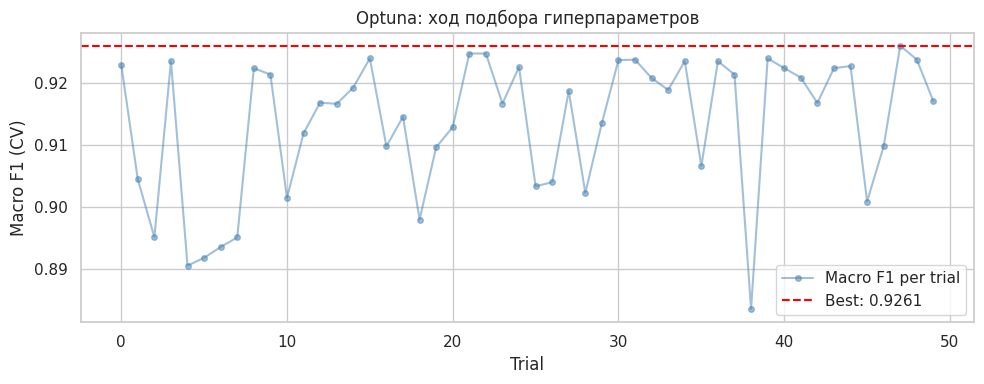

In [7]:
trials_df = study.trials_dataframe()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    trials_df["number"],
    trials_df["value"],
    alpha=0.5,
    color="steelblue",
    marker="o",
    markersize=4,
    label="Macro F1 per trial",
)
ax.axhline(
    study.best_value,
    color="red",
    linestyle="--",
    label=f"Best: {study.best_value:.4f}",
)
ax.set_xlabel("Trial")
ax.set_ylabel("Macro F1 (CV)")
ax.set_title("Optuna: ход подбора гиперпараметров")
ax.legend()
plt.tight_layout()
plt.savefig("optuna_trials.png", dpi=150, bbox_inches="tight")
plt.show()

**Анализ графика подбора гиперпараметров:**

TPE-сэмплер демонстрирует эффективную работу: уже с первых trials модель показывает высокое качество (~0.923), что говорит о том, что задача хорошо решается Gradient Boosting при широком диапазоне параметров. Разброс значений по всем 50 trials невелик — от 0.885 до 0.926, что свидетельствует об устойчивости модели. Лучший результат 0.9261 достигнут ближе к концу оптимизации — TPE уточняет поиск по мере накопления информации о пространстве гиперпараметров. Отдельные "провалы" (до 0.885) соответствуют trials с неудачными комбинациями, например слишком маленьким `learning_rate` без достаточного числа деревьев.

---
## 5. Обучение финальной модели

Финальная модель обучается на **всей тренировочной выборке** (778 объектов) с лучшими найденными гиперпараметрами. Использование всех тренировочных данных (а не одного из фолдов CV) максимизирует объём обучающей информации.

In [8]:
best_params = study.best_params
best_params["random_state"] = RANDOM_STATE

gb_model = GradientBoostingClassifier(**best_params)
gb_model.fit(X_train, y_train)

print("Модель обучена с параметрами:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Модель обучена с параметрами:
  n_estimators: 305
  max_depth: 3
  learning_rate: 0.01117550395380505
  subsample: 0.8654845255820633
  min_samples_leaf: 2
  random_state: 15


---
## 6. Оценка качества на тестовой выборке

In [9]:
y_pred = gb_model.predict(X_test)

test_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1 на тестовой выборке: {test_f1:.4f}")
print()
print(classification_report(
    y_test,
    y_pred,
    target_names=["Новичок", "Средний", "Эксперт"],
))

Macro F1 на тестовой выборке: 0.8991

              precision    recall  f1-score   support

     Новичок       0.98      0.71      0.82        75
     Средний       0.79      0.99      0.88        82
     Эксперт       1.00      1.00      1.00        38

    accuracy                           0.88       195
   macro avg       0.92      0.90      0.90       195
weighted avg       0.90      0.88      0.88       195



**Анализ результатов классификации:**

Итоговый Macro F1 = **0.8991** — существенный прирост по сравнению с логистической регрессией из ДЗ 2 (~0.85). По классам картина следующая:

- **Эксперт** — идеальное распознавание: precision=1.00, recall=1.00, F1=1.00. Все 38 экспертов классифицированы верно. Этот класс наиболее чётко отличается по признакам — высокая частота и длительность тренировок создают хорошо разделимый кластер.
- **Средний** — очень высокое качество: precision=0.79, recall=0.99, F1=0.88. Recall близок к единице — модель почти не пропускает средних клиентов. Precision ниже из-за того, что 22 новичка ошибочно попадают в этот класс.
- **Новичок** — наибольшая сложность: precision=0.98, recall=0.71, F1=0.82. Высокая precision означает, что когда модель предсказывает "новичок" — она почти всегда права. Но recall=0.71 говорит, что 22 из 75 настоящих новичков модель относит к Среднему классу. Это объяснимо: граница между новичком и средним уровнем размыта — оба имеют схожий состав тела, и различие лишь в накопленном опыте.

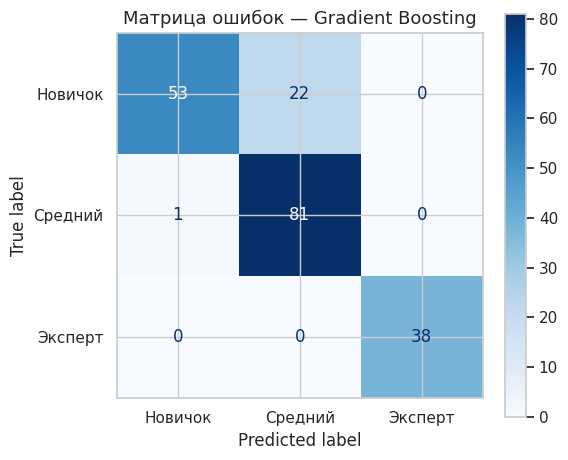

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Новичок", "Средний", "Эксперт"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Матрица ошибок — Gradient Boosting", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_gb.png", dpi=150, bbox_inches="tight")
plt.show()

**Анализ матрицы ошибок:**

Матрица наглядно подтверждает выводы из classification report. Диагональ доминирует: 53 + 81 + 38 = 172 верных предсказания из 195 (точность 88%). Единственная значимая зона ошибок — 22 новичка, предсказанных как Средний класс. Ошибок в сторону класса Эксперт нет вообще: ни один новичок или средний клиент не был ошибочно принят за эксперта, и наоборот. Это говорит о том, что Gradient Boosting чётко усвоил, что экспертный уровень — это отдельная, хорошо различимая категория.

---
## 7. Глобальная интерпретация модели

### 7.1 Feature Importance (встроенная в модель)

Встроенная важность Gradient Boosting показывает **среднее уменьшение примеси (impurity reduction)** при каждом разбиении по данному признаку, усреднённое по всем деревьям. Это быстрый первичный взгляд, но у него есть ограничение: он может завышать важность непрерывных признаков с большим числом уникальных значений.

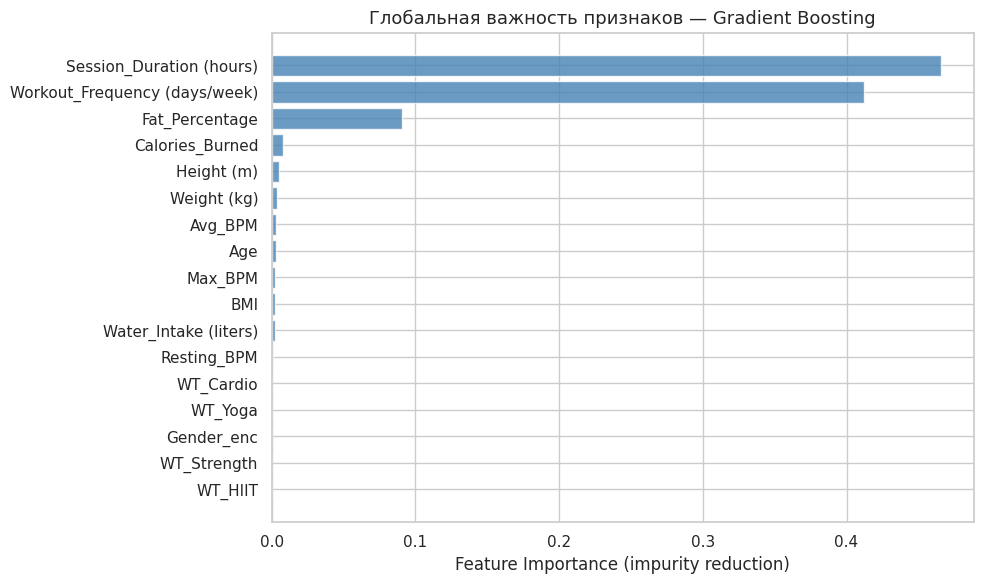

In [11]:
feature_names = list(X_train.columns)
importances = gb_model.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    [feature_names[i] for i in indices],
    importances[indices],
    color="steelblue",
    alpha=0.8,
)
ax.set_xlabel("Feature Importance (impurity reduction)")
ax.set_title("Глобальная важность признаков — Gradient Boosting", fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**Анализ Feature Importance:**

Два признака доминируют с огромным отрывом от остальных:
- **`Session_Duration`** (~0.47) — длительность тренировки является самым информативным признаком. Это логично: опытные спортсмены тренируются значительно дольше новичков.
- **`Workout_Frequency`** (~0.41) — частота посещений зала. Вместе с `Session_Duration` эти два признака объясняют около 88% суммарной важности модели.
- **`Fat_Percentage`** (~0.09) занимает третье место — процент жира служит дополнительным разграничителем, особенно между новичками и экспертами.

Остальные 14 признаков (пульсовые показатели, тип тренировки, пол, возраст, вес, рост) практически не вносят вклада. Особенно примечательно, что тип тренировки (`WT_*`) не имеет значения — модель правильно уловила вывод из ДЗ 1: тип тренировки не определяет уровень опыта клиента.

### 7.2 SHAP — глобальная интерпретация

SHAP (SHapley Additive exPlanations) — более надёжный метод интерпретации, основанный на теории кооперативных игр. В отличие от impurity importance, SHAP:
- Учитывает взаимодействия между признаками.
- Показывает **направление** влияния каждого признака (повышает или понижает вероятность класса).
- Даёт разбивку важности по каждому классу отдельно.

Используется `PermutationExplainer` — универсальный метод, работающий через случайное перемешивание значений признаков и измерение падения качества.

PermutationExplainer explainer: 196it [01:48,  1.72it/s]


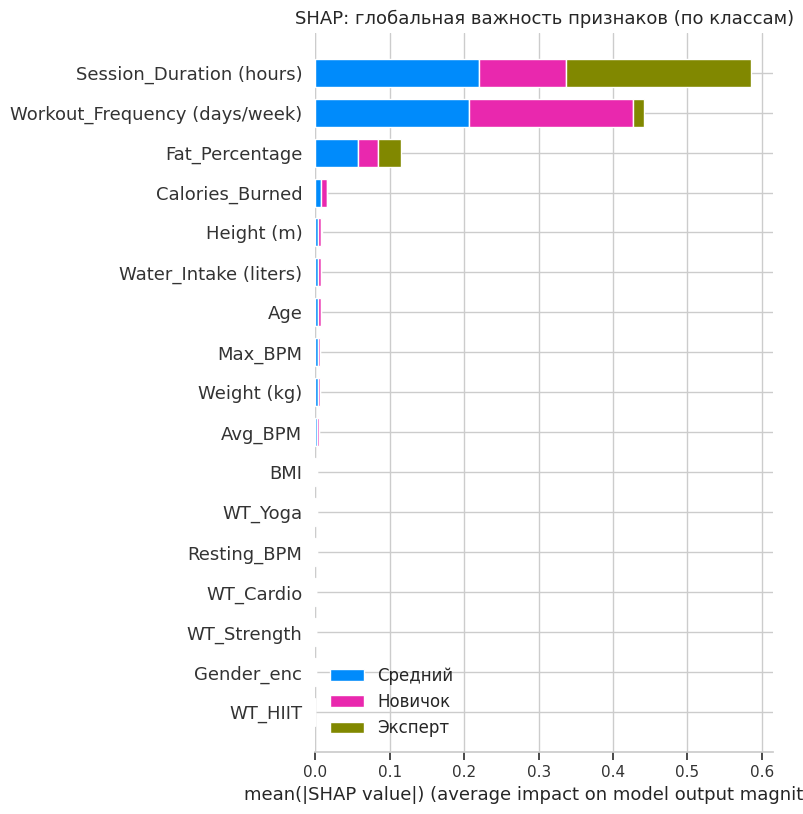

In [12]:
explainer = shap.explainers.Permutation(gb_model.predict_proba, X_train)
shap_values = explainer(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    class_names=["Новичок", "Средний", "Эксперт"],
    plot_type="bar",
    show=False,
)
plt.title("SHAP: глобальная важность признаков (по классам)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_global_bar.png", dpi=150, bbox_inches="tight")
plt.show()

**Анализ SHAP bar plot:**

SHAP подтверждает и уточняет картину Feature Importance, добавляя разбивку по классам:

- **`Session_Duration`** — важнейший признак для всех трёх классов, но особенно значим для класса **Эксперт** (тёмно-жёлтый столбец самый длинный ~0.58). Длительность тренировки — главный маркер экспертного уровня.
- **`Workout_Frequency`** — второй по важности, примерно одинаково значим для Эксперта и Среднего класса (~0.43–0.44). Частота посещений хорошо разделяет все три группы.
- **`Fat_Percentage`** — важен преимущественно для разграничения Новичка и Эксперта. Вносит сопоставимый вклад в оба этих класса.
- **Средний класс** не имеет собственного сильного маркера — он определяется по остаточному принципу как "не новичок и не эксперт". Это объясняет, почему именно этот класс создаёт наибольшую путаницу с Новичками.
- Все остальные признаки (пульс, тип тренировки, пол, антропометрия) имеют близкое к нулю SHAP-влияние во всех классах.

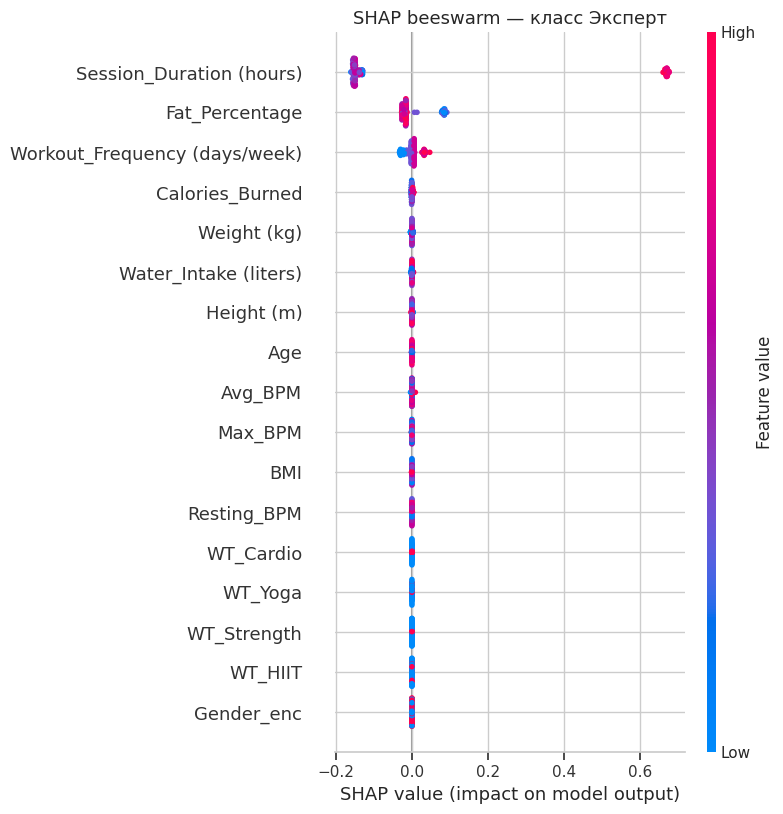

In [13]:
# Beeswarm plot для класса "Эксперт"
shap.summary_plot(
    shap_values[:, :, 2].values,
    X_test,
    feature_names=feature_names,
    show=False,
)
plt.title("SHAP beeswarm — класс Эксперт", fontsize=13)
plt.tight_layout()
plt.savefig("shap_beeswarm_expert.png", dpi=150, bbox_inches="tight")
plt.show()

**Анализ SHAP beeswarm для класса Эксперт:**

Beeswarm-график показывает не только важность, но и **направление** влияния каждого признака. Цвет точки — значение признака (красный = высокое, синий = низкое), положение по оси X — SHAP-значение (вправо = повышает вероятность класса Эксперт).

- **`Session_Duration`**: высокое значение (красная точка) даёт огромный положительный SHAP ~+0.65 — это самый сильный одиночный сигнал во всей модели. Короткие тренировки (синие точки) дают отрицательный SHAP ~−0.2.
- **`Fat_Percentage`**: работает в обратную сторону — высокий процент жира (красные точки) слегка снижает вероятность класса Эксперт, низкий процент жира (синие точки) — повышает. Физиологически корректно: у тренированных людей процент жира ниже.
- **`Workout_Frequency`**: аналогично `Session_Duration` — высокая частота тренировок повышает вероятность класса Эксперт.
- Все остальные признаки сосредоточены плотным облаком около нуля — их влияние на класс Эксперт пренебрежимо мало.



---
## 8. Локальная интерпретация

Локальная интерпретация объясняет предсказание модели для **конкретного объекта**: какие признаки и насколько сдвинули предсказание от среднего по выборке (base value = E[f(X)]) к итоговому значению f(x). Красные стрелки повышают вероятность класса, синие — понижают.

Выбираем по одному верно классифицированному примеру каждого класса.

In [14]:
y_test_arr = y_test.values
sample_indices = {}
for lvl in [1, 2, 3]:
    for i, (true, pred) in enumerate(zip(y_test_arr, y_pred)):
        if true == lvl and pred == lvl:
            sample_indices[lvl] = i
            break

print("Выбранные примеры (верно классифицированные):")
for lvl, idx in sample_indices.items():
    print(f"  Класс {lvl} ({level_names[lvl]}): объект #{idx}")

Выбранные примеры (верно классифицированные):
  Класс 1 (Новичок): объект #5
  Класс 2 (Средний): объект #0
  Класс 3 (Эксперт): объект #2


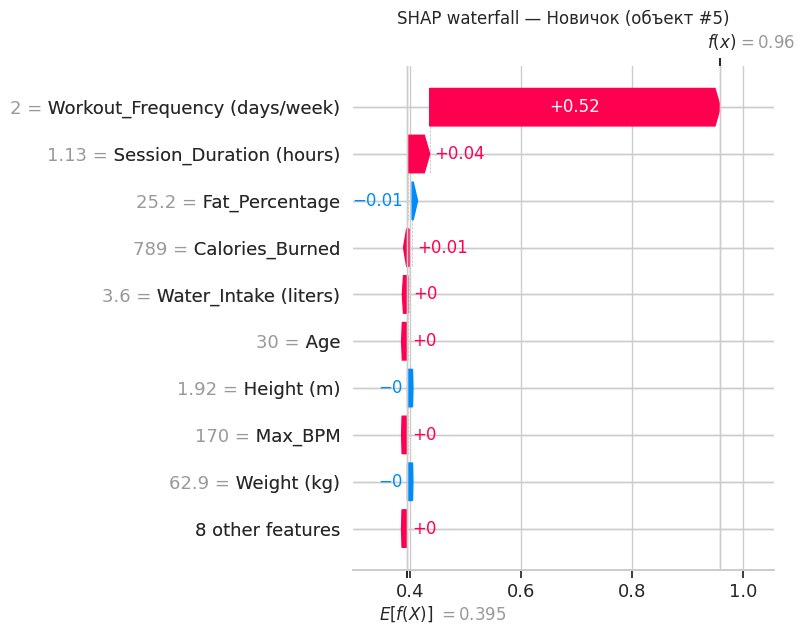

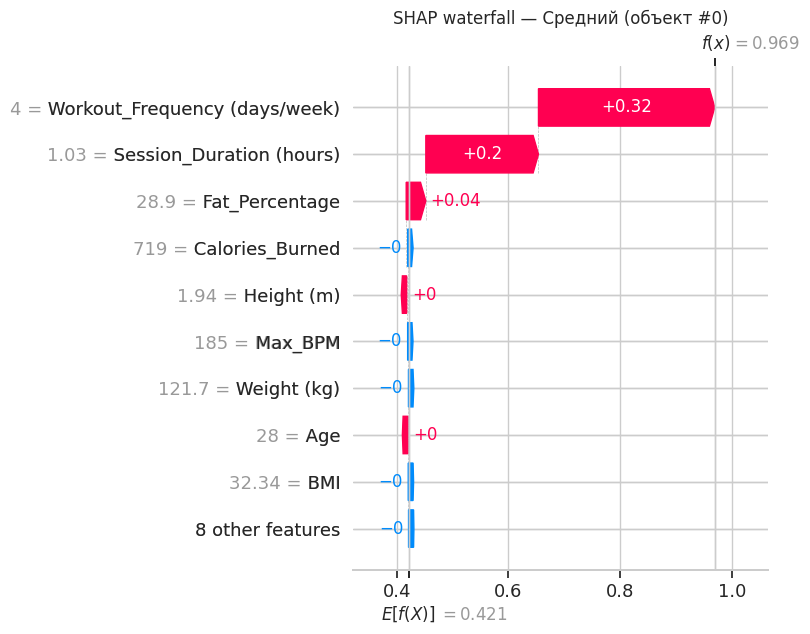

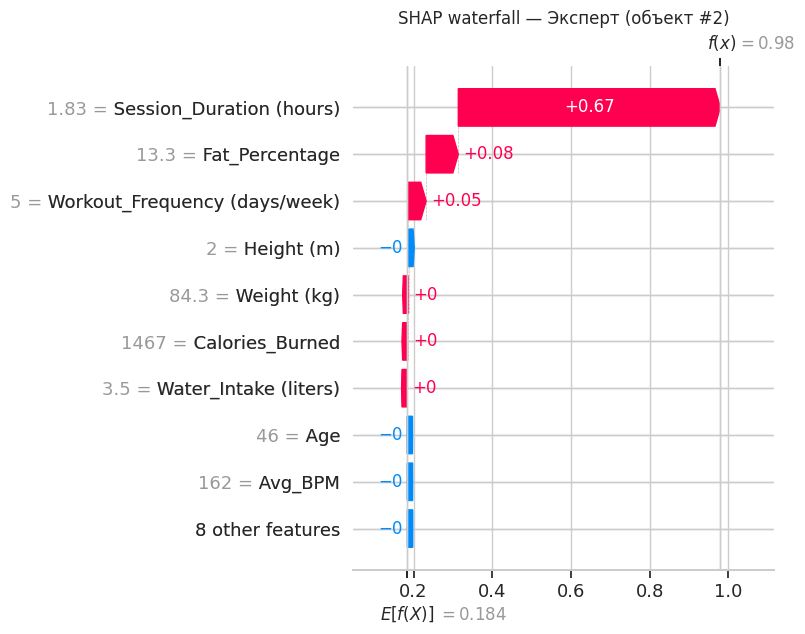

In [15]:
class_idx_map = {1: 0, 2: 1, 3: 2}

for lvl, idx in sample_indices.items():
    cls_idx = class_idx_map[lvl]
    shap.waterfall_plot(shap_values[idx, :, cls_idx], show=False)
    plt.title(f"SHAP waterfall — {level_names[lvl]} (объект #{idx})", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"shap_waterfall_{lvl}.png", dpi=150, bbox_inches="tight")
    plt.show()

**Анализ SHAP waterfall — Новичок (объект #5):**

Базовое значение модели E[f(X)] = 0.395, финальное предсказание f(x) = 0.96 — модель уверенно классифицирует объект как Новичка.

Признаки объекта и их вклад:
- **`Workout_Frequency = 2`** дней в неделю → **+0.52** — главный вклад. Редкие тренировки (всего 2 раза в неделю) являются самым сильным сигналом новичка. Именно это значение почти полностью "достраивает" предсказание от базового уровня 0.395 до финального 0.96.
- **`Session_Duration = 1.13`** часа → **+0.04** — короткие тренировки дополнительно подтверждают новичковый уровень.
- **`Fat_Percentage = 25.2%`** → **−0.01** — небольшой отрицательный вклад: этот процент жира не является экстремально высоким, поэтому признак чуть снижает уверенность в классе Новичок.
- Остальные признаки (возраст 30, рост 1.92, вес 62.9, пульс, калории) практически не влияют на предсказание.

